#ShieldSight PPE Detection System

ShieldSight is a PPE safety detection system designed to identify whether workers are wearing required protective equipment.

The model focuses on five classes:
*Person, Hardhat, NO-Hardhat, Safety Vest, and NO-Safety Vest.

## Setup
Install Ultralytics
Imports

In [64]:
#  Install required package
!pip install ultralytics

# clone the repo
!git clone https://github.com/bgreen2026/ShieldSight-PPE-Detection.git

from ultralytics import YOLO
import matplotlib.pyplot as plt

print("Ultralytics installed successfully!")

Cloning into 'ShieldSight-PPE-Detection'...
remote: Enumerating objects: 92, done.
remote: Counting objects: 100% (92/92), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 92 (delta 31), reused 3 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (92/92), 8.15 MiB | 7.82 MiB/s, done.
Resolving deltas: 100% (31/31), done.
Ultralytics installed successfully!


Load Model

In [65]:
model = YOLO("/content/ShieldSight-PPE-Detection/models/best.pt")

print("Model loaded!")

Model loaded!


In [66]:
def run_demo(image_path):
    results = model(image_path)
    results[0].show()
    for box in results[0].boxes:
        name = model.names[int(box.cls[0])]
        conf = float(box.conf[0])
        print(f"Detected: {name} ({conf:.2f})")

# Test 1: PPE Compliant Workers

This test evaluates ShieldSight's ability to identify workers wearing required PPE, including hardhats and safety vests.


image 1/1 /content/ShieldSight-PPE-Detection/data/demo/Test PPE image.png: 448x640 2 Hardhats, 2 Persons, 2 Safety Vests, 187.1ms
Speed: 3.2ms preprocess, 187.1ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)


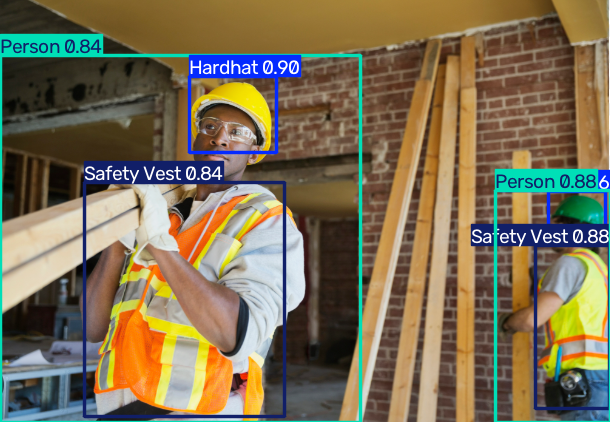

Detected: Hardhat (0.90)
Detected: Person (0.88)
Detected: Safety Vest (0.88)
Detected: Hardhat (0.86)
Detected: Person (0.84)
Detected: Safety Vest (0.84)


In [67]:
run_demo("/content/ShieldSight-PPE-Detection/data/demo/Test PPE image.png")

## Test 2: Multiple Workers and PPE Detection

This test evaluates ShieldSight on a more complex scene with multiple workers and different PPE conditions.


image 1/1 /content/ShieldSight-PPE-Detection/data/demo/test_ppe_image2.png: 544x640 3 Hardhats, 1 NO-Safety Vest, 3 Persons, 2 Safety Vests, 226.1ms
Speed: 3.7ms preprocess, 226.1ms inference, 1.1ms postprocess per image at shape (1, 3, 544, 640)


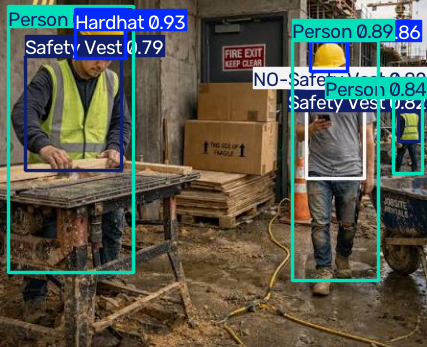

Detected: Hardhat (0.93)
Detected: Person (0.89)
Detected: Person (0.89)
Detected: Hardhat (0.86)
Detected: Person (0.84)
Detected: Safety Vest (0.82)
Detected: NO-Safety Vest (0.82)
Detected: Hardhat (0.81)
Detected: Safety Vest (0.79)


In [61]:
run_demo("/content/ShieldSight-PPE-Detection/data/demo/test_ppe_image2.png")

## Test 3: Missing Hardhat - Failure Case

This test evaluates ShieldSight's ability to identify a worker who is not wearing a hardhat.


image 1/1 /content/ShieldSight-PPE-Detection/data/demo/test_ppe_image3.png: 384x640 1 Hardhat, 2 Persons, 1 Safety Vest, 133.7ms
Speed: 2.4ms preprocess, 133.7ms inference, 1.1ms postprocess per image at shape (1, 3, 384, 640)


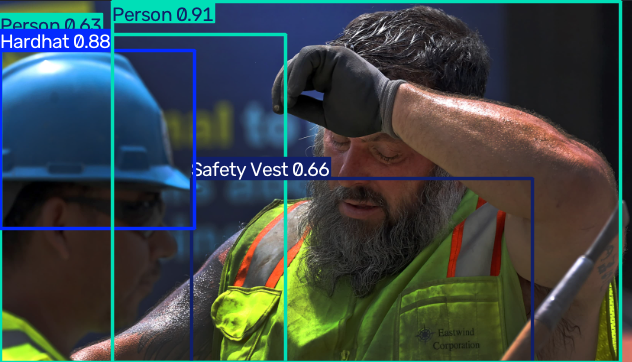

Detected: Person (0.91)
Detected: Hardhat (0.88)
Detected: Safety Vest (0.66)
Detected: Person (0.63)


In [62]:
run_demo("/content/ShieldSight-PPE-Detection/data/demo/test_ppe_image3.png")

## Test 4: Crowded Construction Scene

This test evaluates ShieldSight in a more challenging environment with multiple workers, overlapping objects, and workers at different distances from the camera.


image 1/1 /content/ShieldSight-PPE-Detection/data/demo/test_ppe_image4.png: 416x640 10 Hardhats, 16 Persons, 12 Safety Vests, 144.9ms
Speed: 3.7ms preprocess, 144.9ms inference, 1.1ms postprocess per image at shape (1, 3, 416, 640)


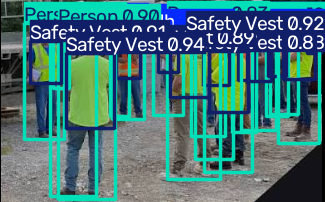

Detected: Safety Vest (0.94)
Detected: Safety Vest (0.92)
Detected: Safety Vest (0.91)
Detected: Person (0.90)
Detected: Safety Vest (0.89)
Detected: Safety Vest (0.88)
Detected: Person (0.87)
Detected: Hardhat (0.85)
Detected: Person (0.85)
Detected: Hardhat (0.84)
Detected: Safety Vest (0.84)
Detected: Safety Vest (0.83)
Detected: Safety Vest (0.83)
Detected: Person (0.83)
Detected: Hardhat (0.81)
Detected: Hardhat (0.79)
Detected: Hardhat (0.78)
Detected: Person (0.78)
Detected: Safety Vest (0.76)
Detected: Person (0.75)
Detected: Hardhat (0.73)
Detected: Person (0.73)
Detected: Person (0.72)
Detected: Person (0.66)
Detected: Hardhat (0.63)
Detected: Safety Vest (0.59)
Detected: Hardhat (0.59)
Detected: Hardhat (0.57)
Detected: Safety Vest (0.56)
Detected: Person (0.56)
Detected: Person (0.54)
Detected: Hardhat (0.50)
Detected: Person (0.50)
Detected: Person (0.49)
Detected: Person (0.36)
Detected: Safety Vest (0.36)
Detected: Person (0.31)
Detected: Person (0.29)


In [63]:
run_demo("/content/ShieldSight-PPE-Detection/data/demo/test_ppe_image4.png")

# Final Model Results

*   mAP50: 0.788
*   mAP50-95: 0.473

*   Precision: 0.888
*   Recall: 0.705

The final ShieldSight model achieved an mAP50 of 0.788. The model performed especially well when detecting Hardhats and Safety Vests, while NO-Hardhat was the most challenging class.